<a href="https://colab.research.google.com/github/hamza-jpg/Deep-Learning-Practice-Projects/blob/main/Linear_Regression_and_Gradient_Descent_from_Scratch.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# Loading Dependencies

import numpy as np
import matplotlib.pyplot as plt

In [8]:
# My Custom Linear Regression Class

class MyLinearRegression:

  # Constructor
  def __init__(self, learning_rate = 0.01, epochs = 1000):
    self.lr = learning_rate
    self.epochs = epochs
    self.weights = None
    self.bias = None
    self.loss_history = []

  def fit(self, X, y):
    n_samples, n_features = X.shape
    self.weights = np.zeros((n_features, 1))
    self.bias = 0.0
    self.loss_history = []

    # Gradient Descent Loop
    for epoch in range(self.epochs):

      # Linear eq. for prediction function
      y_pred = np.dot(X, self.weights) + self.bias

      # Loss (MSE)
      error = y_pred - y
      mse = np.mean(error ** 2)
      self.loss_history.append(mse)

      # Gradient Calculations
      dw = (2 / n_samples) * np.dot(X.T, error)
      db = (2 / n_samples) * np.sum(error)

      # Updating Weights and Biasses
      self.weights -= self.lr * dw
      self.bias -= self.lr * db

      if epoch % (self.epochs // 10) == 0:
        print(f"Epoch {epoch:4d} | Loss (MSE): {mse:.4f}")

  def predict(self, X):
    return np.dot(X, self.weights) + self.bias

Epoch    0 | Loss (MSE): 64.2796
Epoch   20 | Loss (MSE): 0.3587
Epoch   40 | Loss (MSE): 0.2411
Epoch   60 | Loss (MSE): 0.2116
Epoch   80 | Loss (MSE): 0.2041
Epoch  100 | Loss (MSE): 0.2023
Epoch  120 | Loss (MSE): 0.2018
Epoch  140 | Loss (MSE): 0.2017
Epoch  160 | Loss (MSE): 0.2017
Epoch  180 | Loss (MSE): 0.2016

--- Results ---
Model Weight (w): 2.8863 (Expected: ~3.0)
Model Bias (b): 5.1061 (Expected: ~5.0)


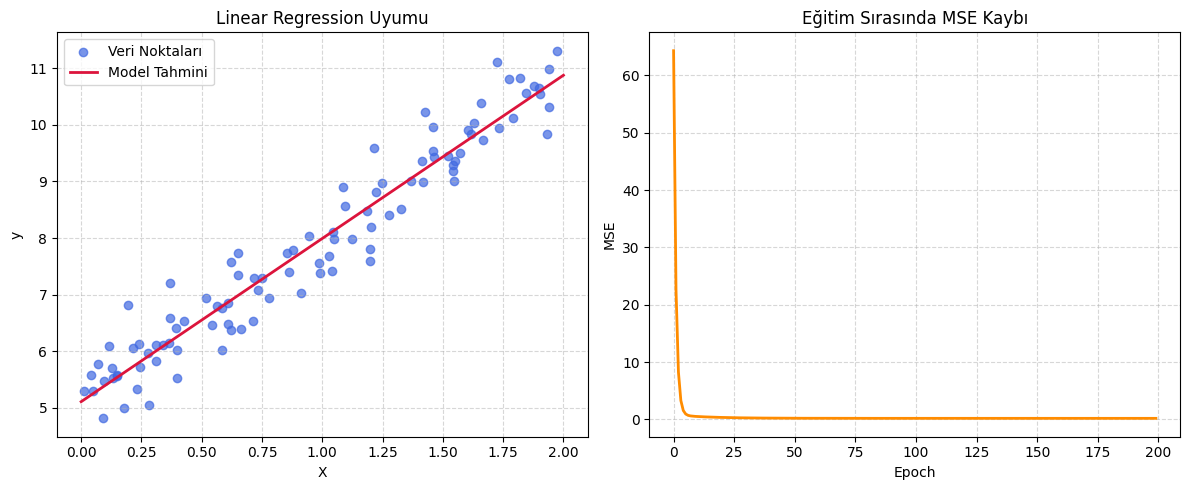

In [9]:
# Testing and Visualization

if __name__ == "__main__":

  # Dummy data generation
  np.random.seed(42)
  X = 2 * np.random.rand(100, 1)

  # Real coefs
  y = 3 * X + 5 + np.random.randn(100, 1) * 0.5

  # Training the model
  model = MyLinearRegression(learning_rate = 0.1, epochs = 200)
  model.fit(X, y)

  print("\n--- Results ---")
  print(f"Model Weight (w): {model.weights[0, 0]:.4f} (Expected: ~3.0)")
  print(f"Model Bias (b): {model.bias:.4f} (Expected: ~5.0)")

  # Plotting the regression line
  fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

  ax1.scatter(X, y, color="royalblue", label="Veri Noktaları", alpha=0.7)
  x_line = np.linspace(0, 2, 100).reshape(-1, 1)
  y_line = model.predict(x_line)
  ax1.plot(x_line, y_line, color="crimson", linewidth=2, label="Model Tahmini")
  ax1.set_title("Linear Regression Uyumu")
  ax1.set_xlabel("X")
  ax1.set_ylabel("y")
  ax1.legend()
  ax1.grid(True, linestyle="--", alpha=0.5)

  # Plotting the loss curve
  ax2.plot(range(len(model.loss_history)), model.loss_history, color="darkorange", linewidth=2)
  ax2.set_title("Eğitim Sırasında MSE Kaybı")
  ax2.set_xlabel("Epoch")
  ax2.set_ylabel("MSE")
  ax2.grid(True, linestyle="--", alpha=0.5)

  plt.tight_layout()
  plt.show()
